# Generar trajectòries

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat 
pel següent sistema d'EDOs, on $f(t)=sin(t)$.
$$x'=y + \epsilon f(t)$$ $$y'=x-x^3$$

In [484]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from typing import Tuple, Iterable

In [485]:
def edo_duffing_soroll(t, z, random=1, epsilon=0.05, funcio_soroll=np.sin):
    """Paràmetres:
        t: temps
        z: posició al pla R^2
        random: nombre real aleatori entre 0 i 2
        epsilon: paràmetre entre 0 i 1 que regula el soroll
        funcio_soroll: pertorbació que depèn del temps
    Retorna el camp vectorial del sistema d'EDOs x'=y+epsilon*random*f(t); y'=x-x^3.
    """
    x, y = z
    soroll = epsilon *  random * funcio_soroll(t)
    camp_vectorial = [y + soroll, x - x**3]
    return np.array(camp_vectorial)

##### Paràmetres

In [486]:
epsilon = 0.05
funcio_soroll = np.sin
dimensio = 2
t_span = (0, 10)
t_steps = 500
t_valors = np.linspace(t_span[0], t_span[1], t_steps)

x_min, x_max = (-1.5, 1.5)
y_min, y_max = (-1.5, 1.5)
step_size_initial_condition_mesh = 0.25

# Gràfica
radi = 0.3
centre_esquerre = (-1, 0)
centre_dret = (1, 0)
centre_nord = (0, 1)
centre_sud = (0, -1)
resolucio_grafica = 2000

### Gràfiques

In [487]:
def grafica_circumferencia(centre: Tuple[float, float],
                           radi: float, 
                           nom_regio:str,
                           resolucio: int) -> None:
    theta = np.linspace(0, 2*np.pi, resolucio)
    a, b = centre
    xx = radi*np.cos(theta) + a
    yy = radi*np.sin(theta)
    plt.plot(xx, yy + b, 'black')
    plt.plot(xx, - yy + b, 'black')
    plt.annotate(nom_regio, centre)

def grafica_regio(nom_regio: str, radi: float, centres: list[Tuple[float, float]], resolucio: int) -> None:
    for centre in centres:
        grafica_circumferencia(centre, radi, nom_regio, resolucio)

def grafica_regions_A_B(radi: float, resolucio: int) -> None:
    grafica_regio('A', radi, [centre_esquerre, centre_dret], resolucio)
    grafica_regio('B', radi, [centre_nord, centre_sud], resolucio)

In [488]:
def grafica_trajectories(trajectories: np.ndarray,
                         dibuixa_regions: bool = False,
                         desa_pdf: bool = False, 
                         radi: float = radi, 
                         resolucio: int = resolucio_grafica
                         ) -> None:
    if dibuixa_regions:
        grafica_regions_A_B(radi, resolucio)
    for trajectoria in trajectories:
        coordenades_x = trajectoria[:,0]
        coordenades_y = trajectoria[:,1]
        plt.plot(coordenades_x, coordenades_y)
    for trajectoria in trajectories:
        coordenades_x = trajectoria[:,0]
        coordenades_y = trajectoria[:,1]
        pos_inicial = (coordenades_x[0], coordenades_y[0])
        inici_string = f'Inici = ({pos_inicial[0]:.2f}, {pos_inicial[1]:.2f})'
        plt.plot(pos_inicial[0], pos_inicial[1], '-o', label=inici_string, color='grey')
        pos_final = (coordenades_x[-1], coordenades_y[-1])
        final_string = f'Final = ({pos_final[0]:.2f}, {pos_final[1]:.2f})'
        plt.plot(pos_final[0], pos_final[1], '-o', label=final_string, color='red')
    plt.xlabel('x')
    plt.ylabel('y') 
    # plt.legend(); 
    plt.grid()
    plt.gca().set_aspect('equal')
    if desa_pdf:
        plt.savefig('edo.pdf')
    plt.show()

In [489]:
def grafica_punts(punts: Iterable, dibuixa_regions=False, radi=radi, resolucio=resolucio_grafica) -> None:
    """punts: conjunt de punts a R^2. Exemple: [[0,1], [0.5,1], [1,1]]"""
    if dibuixa_regions:
        grafica_regions_A_B(radi, resolucio)
    for punt in punts:
        plt.plot(punt[0], punt[1], 'o', markersize=8, color="grey")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Condicions inicials')
    plt.grid()
    plt.gca().set_aspect('equal')
    plt.show()

### 1. Generar $n$ posicions inicials aleatòries

In [490]:
def generar_malla_condicions_inicials(step_size: float) -> Tuple[np.ndarray, int]:
    x = np.arange(x_min, x_max + step_size, step_size)
    y = np.arange(y_min, y_max + step_size, step_size)
    num_x = len(x)
    num_y = len(y)
    num_condicions_inicals = num_x * num_y
    malla = np.zeros((num_condicions_inicals, dimensio))
    for i in range(len(x)):
        for j in range(len(y)):
            malla[i * num_y + j] = [x[i], y[j]]
    return malla, num_condicions_inicals

Nombre de trajectories = 169


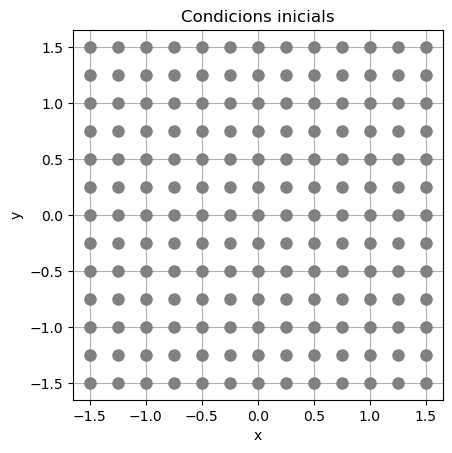

In [491]:
condicions_inicials, num_trajectories = generar_malla_condicions_inicials(step_size_initial_condition_mesh)
print(f"Nombre de trajectories = {num_trajectories}")
grafica_punts(condicions_inicials, dibuixa_regions=False)

### 2. Generar $n$ trajectòries, una per a cada posició inicial

In [492]:
def generar_trajectories(edo,
                         condicions_inicials: np.ndarray,
                         t_span: Tuple[float, float],
                         t_valors: np.ndarray) -> np.ndarray:
    """
    Paràmetres:
        edo: funció que representa el camp vectorial d'una EDO
        num_trajectories: nombre de trajectòries a generar
        condicions_inicials: llista que conté condicions inicials [x0,y0]
        t_valors: np.array[float], conté els instants de temps on avaluem l'EDO
    
    Cada trajectòria és la solució de l'EDO avaluada en els instants de temps indicats.
    """
    trajectories = np.zeros((num_trajectories, t_steps, dimensio))
    valor_random = np.random.uniform(0, 2)
    for i, ci in enumerate(condicions_inicials):
        # valor_random = np.random.uniform(0, 2)
        arguments_extra = (valor_random, epsilon, funcio_soroll)
        sol = solve_ivp(edo, t_span, ci, t_eval=t_valors, args=arguments_extra)
        trajectoria = np.vstack([sol.y[0], sol.y[1]])
        trajectoria = trajectoria.T
        trajectories[i] = trajectoria
    return trajectories

(Num trajectories, t_steps, dimensio) = (169, 500, 2)


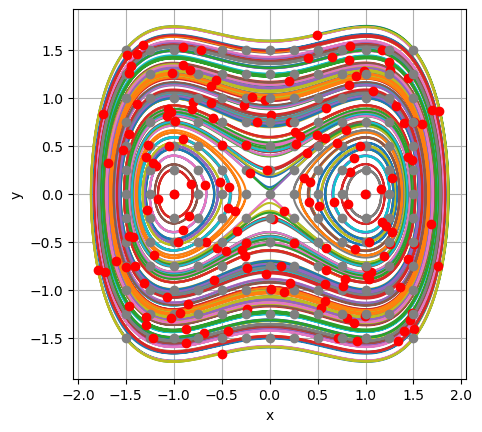

In [493]:
trajectories = generar_trajectories(edo_duffing_soroll, condicions_inicials, t_span, t_valors)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)
grafica_trajectories(trajectories, dibuixa_regions=False)

### 3. Calcular distància $r_{ij}$ entre trajectòries

In [494]:
def calcula_distancia(trajectoria_i: np.ndarray, trajectoria_j: np.ndarray, t_valors: np.ndarray) -> float:
    """Requisit: el pas de temps ha de ser constant"""
    distancia = 0
    num_t_steps = len(t_valors)
    dist_k_old = np.linalg.norm(trajectoria_i[0] - trajectoria_j[0]) # Norma euclidia de vectors en R^2
    for k in range(1, num_t_steps):
        dist_k_new = np.linalg.norm(trajectoria_i[k] - trajectoria_j[k])
        distancia += (dist_k_old + dist_k_new)
        dist_k_old = dist_k_new
    t_span_size = t_valors[-1] - t_valors[0]
    t_step_size = t_valors[1] - t_valors[0]
    return t_step_size * distancia / (2 * t_span_size)

In [495]:
def calcula_pes(i: int, j: int, trajectories: np.ndarray, t_valors: np.ndarray) -> float:
    pes_ij = 1 / calcula_distancia(trajectories[i], trajectories[j], t_valors)
    return pes_ij

### 4. Crear graf $G = (V, E, W)$

Els vèrtexs són cadascuna de les $n$ trajectòries: $V=\{v_1,...,v_n\}$.

Cada aresta $e_{ij}\in E\subseteq V\times V$ està associada al pes $w_{ij}\in W\in\R^{n\times n}$, on $W$ és la matriu de similaritat i $w_{ij} = 1/r_{ij}$. Cada pes representa quant de properes són dues trajectòries ($0 \rightarrow$ poc, i $\infty \rightarrow$ molt).

In [496]:
def calcula_matriu_similaritat(trajectories: np.ndarray, t_valors: np.ndarray, constant_K: float = 1e4) -> np.ndarray:
    num_trajectories = len(trajectories)
    matriu_similaritat = constant_K * np.eye(num_trajectories)
    for i in range(num_trajectories):
        for j in range(i + 1, num_trajectories):
            pes_ij = calcula_pes(i, j, trajectories, t_valors)
            matriu_similaritat[i][j] = pes_ij
            matriu_similaritat[j][i] = pes_ij
    return matriu_similaritat

In [497]:
matriu_similaritat_W = calcula_matriu_similaritat(trajectories, t_valors)
print(matriu_similaritat_W.shape)

(169, 169)


### 5. Calcular el grau

In [498]:
def calcula_grau(vertex: int, matriu_similaritat: np.ndarray) -> float:
    return sum(matriu_similaritat[vertex][j] for j in range(len(matriu_similaritat)))

In [499]:
def calcula_volum(vertexs: Iterable[int], matriu_similaritat: np.ndarray) -> np.ndarray:
    return np.diag([calcula_grau(vertex, matriu_similaritat) for vertex in vertexs])

In [500]:
def calcula_matriu_grau(matriu_similaritat: np.ndarray) -> np.ndarray:
    tots_els_vertexs = range(len(matriu_similaritat))
    return calcula_volum(tots_els_vertexs, matriu_similaritat)

In [501]:
matriu_grau_D = calcula_matriu_grau(matriu_similaritat_W)
print(np.shape(matriu_grau_D))

(169, 169)


### 6. Fer que la matriu de similiaritat $W$ sigui _sparse_ usant $k$-nearest neighbors [opcional]

O bé quedarse només amb els pesos $w_{ij}$ més grans que una tolerància $\epsilon$. (Aquesta $\epsilon$ és diferent de l'$\epsilon$ de l'EDO). L'obectiu de tornar la matriu sparse és per reduir la memòria que ocupa i poder emmagatzemar-la.

#### Trobar la partició que satisfà _mincut_

In [502]:
def pes_del_tall(vertexs_A: Iterable[int], vertexs_B: Iterable[int]) -> float:
    return sum(matriu_similaritat_W[i][j] for i in vertexs_A for j in vertexs_B)

In [503]:
def exemple():
    meitatA = range(num_trajectories//2)
    meitatB = range(num_trajectories//2, num_trajectories)
    print(pes_del_tall(meitatA, meitatB))

### 7. Descomposició espectral: $Lu =\lambda Du \iff D^{-1}Lu=\lambda u$

In [504]:
def calcula_inversa_de_matriu_diagonal(matriu: np.ndarray) -> np.ndarray:
    """Requisit: la matriu diagonal ha de ser invertible."""
    return np.diag(1/np.diag(matriu))

In [505]:
matriu_grau_D_inversa = calcula_inversa_de_matriu_diagonal(matriu_grau_D)
matriu_laplacia_L = matriu_grau_D - matriu_similaritat_W
matriu_per_calcular_vaps = matriu_grau_D_inversa @ matriu_laplacia_L

In [506]:
vaps = np.linalg.eigvals(matriu_per_calcular_vaps)
vaps.sort()
vaps = vaps[1:] # eliminem el VAP més petit perquè és zero
print(vaps)

[0.00787043 0.00803304 0.00824602 0.00846108 0.00864823 0.00880191
 0.00887891 0.00901345 0.00909843 0.00926234 0.00927052 0.00935801
 0.00943477 0.00951552 0.00952371 0.00956027 0.00956906 0.00957512
 0.00965701 0.00975693 0.00976593 0.00981355 0.00991492 0.00999286
 0.01001855 0.01006624 0.01008323 0.01022985 0.01026707 0.01030382
 0.01034745 0.01046894 0.01052555 0.01055156 0.01055199 0.01056547
 0.01062935 0.01063813 0.01065747 0.01069643 0.01071778 0.01072595
 0.01077127 0.01081566 0.01085334 0.01085962 0.01091302 0.01092682
 0.01093256 0.01095758 0.01096303 0.01098237 0.01098505 0.01104435
 0.01105297 0.01108858 0.01113228 0.01120914 0.01123136 0.01123883
 0.01126419 0.01135917 0.01137655 0.01141292 0.01145253 0.01145289
 0.01149197 0.01151104 0.01152615 0.01158099 0.01159817 0.01160686
 0.01161788 0.01166429 0.01168631 0.01169737 0.01170006 0.01172356
 0.01173468 0.01173865 0.0117431  0.01175066 0.01176054 0.01176997
 0.01178086 0.01179402 0.01182214 0.01185127 0.01187511 0.0119

### 8. Estimació del nombre de clústers $k$ = argmin [max($g_i$)]

In [507]:
def diferencia_n_essima(vector: np.ndarray, index: int) -> float:
    return vector[index + 1] - vector[index]

In [508]:
vaps_diferencies = np.array([diferencia_n_essima(vaps, i) for i in range(len(vaps) - 1)])
print(vaps_diferencies)

[1.62612795e-04 2.12978335e-04 2.15061884e-04 1.87145270e-04
 1.53682152e-04 7.70032806e-05 1.34536042e-04 8.49829444e-05
 1.63904939e-04 8.17906097e-06 8.74968753e-05 7.67593723e-05
 8.07514413e-05 8.18632105e-06 3.65606503e-05 8.78955027e-06
 6.05558640e-06 8.18978100e-05 9.99123114e-05 9.00434040e-06
 4.76225650e-05 1.01370332e-04 7.79394508e-05 2.56865879e-05
 4.76867263e-05 1.69925231e-05 1.46624436e-04 3.72160568e-05
 3.67523386e-05 4.36282279e-05 1.21492118e-04 5.66106437e-05
 2.60121878e-05 4.27880401e-07 1.34820821e-05 6.38750260e-05
 8.77863261e-06 1.93409802e-05 3.89568706e-05 2.13504524e-05
 8.17298797e-06 4.53207052e-05 4.43904818e-05 3.76812617e-05
 6.27818631e-06 5.33993503e-05 1.37981096e-05 5.74066522e-06
 2.50175532e-05 5.45195986e-06 1.93419332e-05 2.67522072e-06
 5.93017901e-05 8.62505553e-06 3.56069606e-05 4.37046272e-05
 7.68547139e-05 2.22169451e-05 7.47572601e-06 2.53582672e-05
 9.49760098e-05 1.73846084e-05 3.63672379e-05 3.96111356e-05
 3.58961811e-07 3.908635

In [509]:
num_clusters_k = np.argmax(vaps_diferencies)
print(num_clusters_k)

165
